# CIs for FINN via DDB and PB for Synthetic Data: FINN, PI3NN, DDB/PB and CI Construction

- FINN for PI3NN mean predictor on train data
- PI3NN on train data
- draw DD/P bootstraps
- FINN on bootstraps for CI


In [1]:
from pathlib import Path
import importlib

import numpy as np
import matplotlib.pyplot as plt
import time

import synth_finn.io as fio
import synth_finn.engine as feng
import synth_pi3nn.io as pio
import synth_pi3nn.engine as peng
import synth_ddb.io as dio
import synth_ddb.engine as deng
import synth_pb.io as pbio
import synth_pb.engine as pbeng
import synth_samples

importlib.reload(fio)
importlib.reload(feng)
importlib.reload(pio)
importlib.reload(peng)
importlib.reload(dio)
importlib.reload(deng)
importlib.reload(pbio)
importlib.reload(pbeng)
importlib.reload(synth_samples)

from synth_samples import DDBSamples, PBSamples

Setup directories

In [ ]:
input_dir = Path("../in")
output_dir = Path("../out")
results_dir = output_dir / "synth_results"

finn_results_dir = fio.FINNDir(results_dir / "synth_finn")
pi3nn_results_dir = pio.PI3NNDir(results_dir / "synth_pi3nn")
ddb_results_dir = dio.DDBDir(results_dir / "synth_ddb")
pb_results_dir = pbio.PBDir(results_dir / "synth_pb")

Load data

In [3]:
t_train, x_train, u_train = fio.load_synthetic_data(f"train")
x_train_test, u_train_test = fio.load_synthetic_data(f"train-test")
x_indis_test, u_indis_test = fio.load_synthetic_data(f"in-dis-test")
x_ood_test, u_ood_test = fio.load_synthetic_data(f"out-dis-test")

FINN

In [4]:
dt = time.time()
feng.setup_and_train_model(finn_results_dir, t_train, x_train, u_train)
dt = time.time() - dt
if not (results_dir / "finn_training_time.txt").exists():
    with open(results_dir / "finn_training_time.txt", "w") as file:
        file.write(f"{dt:.2f} s")
    print(f"FINN training time: {dt:.2f} s.")

In [5]:
u_for_learned = np.load(finn_results_dir.u_for_learned_path)
learned = finn_results_dir.best_learned
best_pred_u_train = finn_results_dir.best_pred_u_train
best_pred_u_train_test = finn_results_dir.best_pred_u_train_test
x_train = np.load(finn_results_dir.x_train_path)

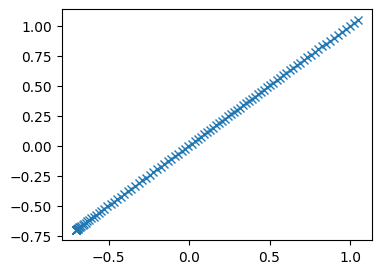

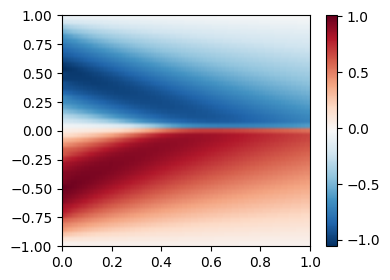

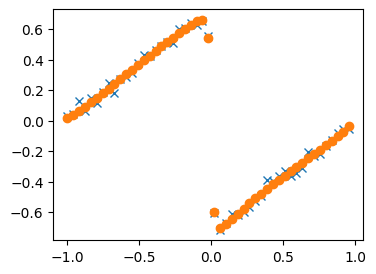

In [6]:
plt.figure(figsize=[4, 3])
plt.plot(learned, learned, 'x', label='Data')

plt.figure(figsize=[4, 3])
plt.imshow(best_pred_u_train.T.squeeze(), extent=[0, 1, -1, 1], origin="lower", aspect="auto", cmap="RdBu_r")
plt.colorbar()

plt.figure(figsize=[4, 3])
plt.plot(x_train, u_train_test, 'x', label='Data')
plt.plot(x_train, best_pred_u_train_test, 'o', label='FINN Prediction')

PI3NN on final timestep data with FINN

In [7]:
quantiles = np.linspace(0.0, 1.0, 41, endpoint=True)
print(quantiles)

[0.    0.025 0.05  0.075 0.1   0.125 0.15  0.175 0.2   0.225 0.25  0.275
 0.3   0.325 0.35  0.375 0.4   0.425 0.45  0.475 0.5   0.525 0.55  0.575
 0.6   0.625 0.65  0.675 0.7   0.725 0.75  0.775 0.8   0.825 0.85  0.875
 0.9   0.925 0.95  0.975 1.   ]


In [8]:
dt = time.time()
peng.compute_quantiles(pi3nn_results_dir, finn_results_dir, quantiles)
dt = time.time() - dt
if not (results_dir / "quantile_computing_time.txt").exists():
    with open(results_dir / "quantile_computing_time.txt", "w") as file:
        file.write(f"{dt:.2f} s")
    print(f"Quantile computing time: {dt:.2f} s.")

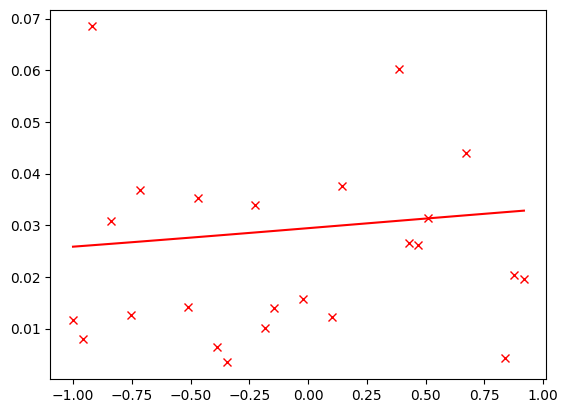

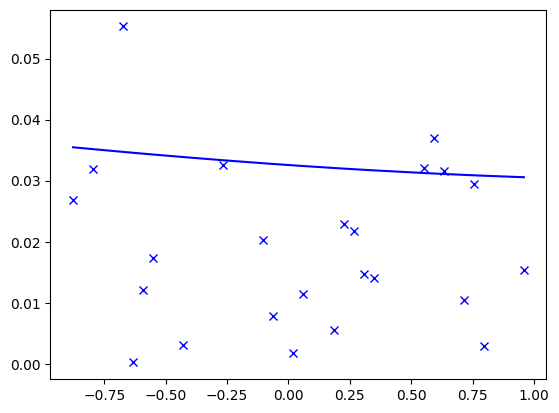

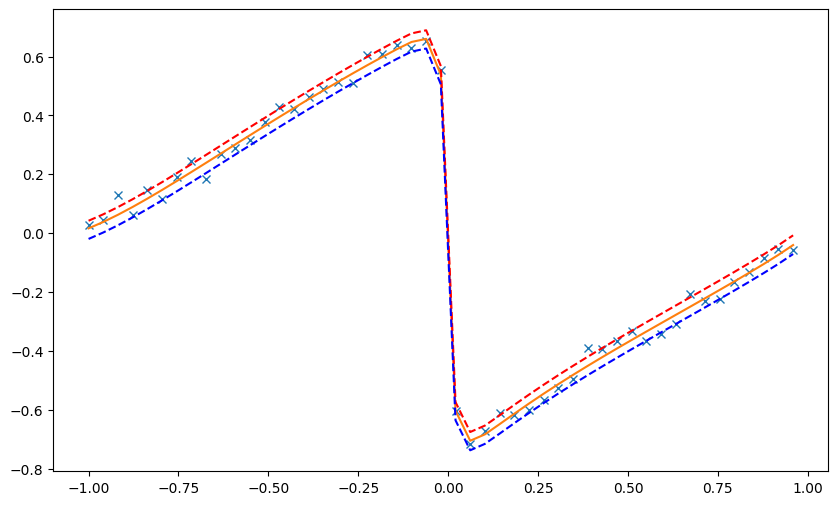

In [9]:
upper_res = np.load(pi3nn_results_dir.u_pred_upper_res_path)
lower_res = np.load(pi3nn_results_dir.u_pred_lower_res_path)
median = np.load(pi3nn_results_dir.u_pred_median_path)

x_upper_res_train = np.load(pi3nn_results_dir.upper_dir / "x_train.npy")
x_lower_res_train = np.load(pi3nn_results_dir.lower_dir / "x_train.npy")
upper_res_train = np.load(pi3nn_results_dir.upper_dir / "u_res_train.npy")
lower_res_train = np.load(pi3nn_results_dir.lower_dir / "u_res_train.npy")
upper_res_pred_train = np.load(pi3nn_results_dir.upper_dir / "u_res_pred_train.npy")
lower_res_train_res_pred_train = np.load(pi3nn_results_dir.lower_dir / "u_res_pred_train.npy")

plt.plot(x_upper_res_train, upper_res_train, 'rx')
plt.plot(x_upper_res_train, upper_res_pred_train, 'r-')
plt.figure()
plt.plot(x_lower_res_train, lower_res_train, 'bx')
plt.plot(x_lower_res_train, lower_res_train_res_pred_train, 'b-')
plt.figure(figsize=[10, 6])
plt.plot(x_train, u_train_test, 'x', label='Data')
plt.plot(x_train, median, '-', label='Median')
plt.plot(x_train, median + upper_res, 'r--', label='Upper Res')
plt.plot(x_train, median - lower_res, 'b--', label='Lower Res')

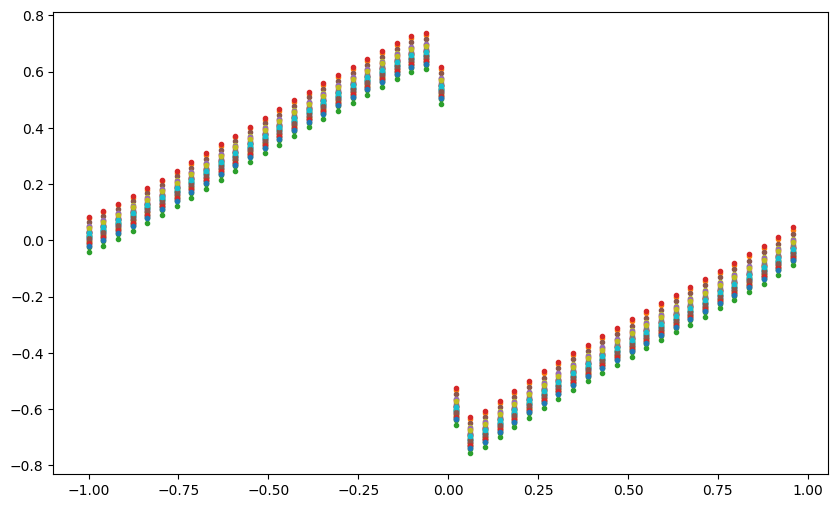

In [10]:
quantiles_data = pi3nn_results_dir.iter_quantiles()

plt.figure(figsize=[10, 6])
for quantile in quantiles_data.keys():
    q_data = quantiles_data[quantile]

    plt.plot(x_train, q_data, ".")

DDB on computed quantiles

In [11]:
dt = time.time()
deng.setup_and_train_ddb(ddb_results_dir, pi3nn_results_dir)
dt = time.time() - dt
if not (results_dir / "ddb_finns_training_time.txt").exists():
    with open(results_dir / "ddb_finns_training_time.txt", "w") as file:
        file.write(f"{dt:.2f} s")
    print(f"DDB FINNs training time: {dt:.2f} s.")

In [12]:
ddb_samples = DDBSamples.from_dir(ddb_results_dir.path)

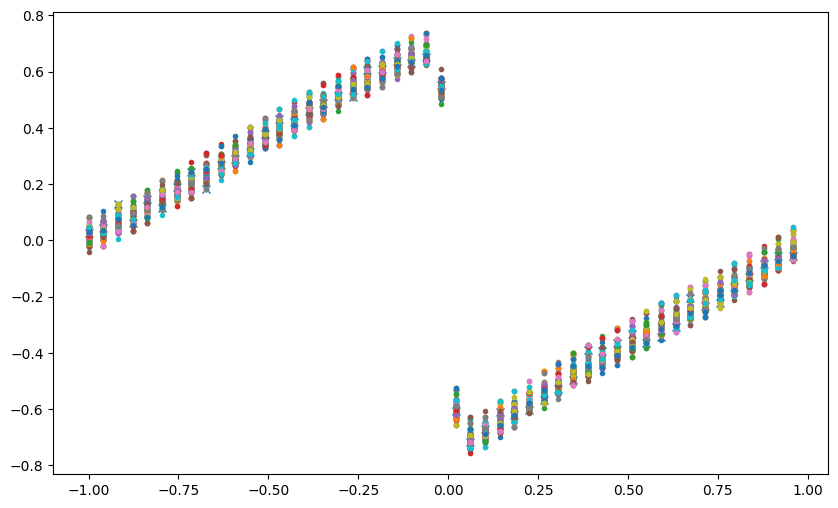

In [13]:
plt.figure(figsize=[10, 6])

u_train = np.load(pi3nn_results_dir.u_data_path)
plt.plot(x_train, u_train, "x")

plt.plot(x_train, ddb_samples.mixed_quantiles, '.')

(49, 70)


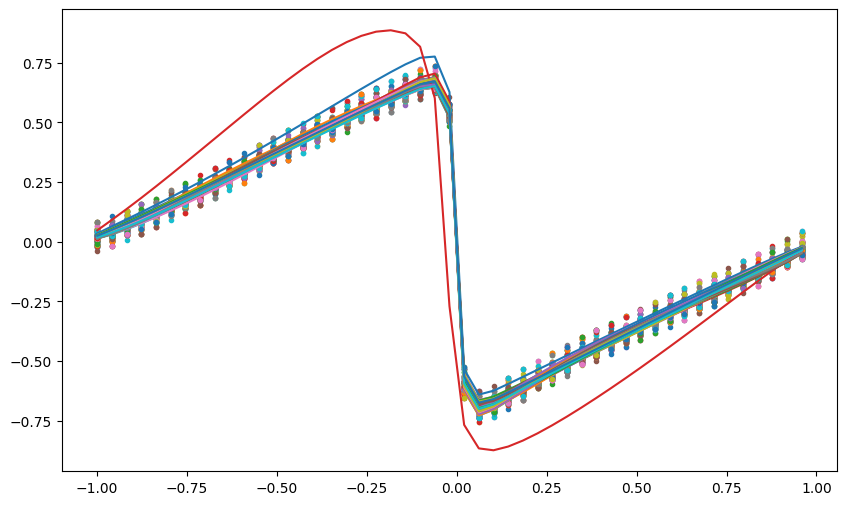

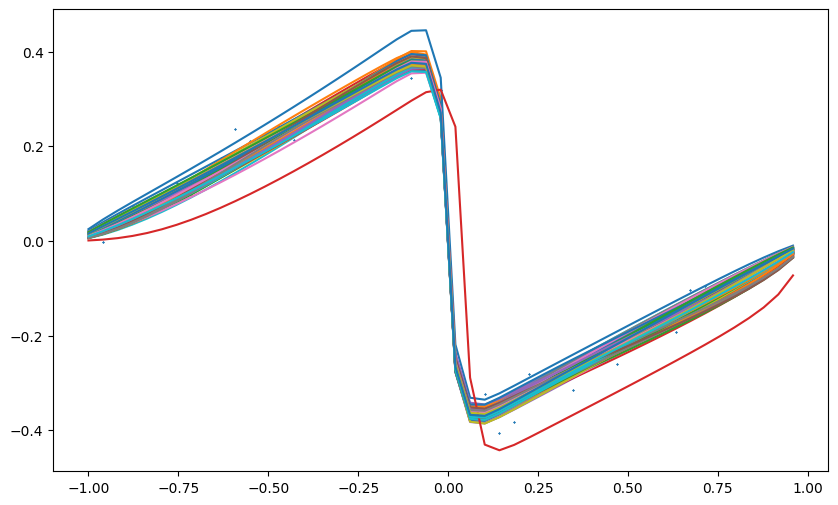

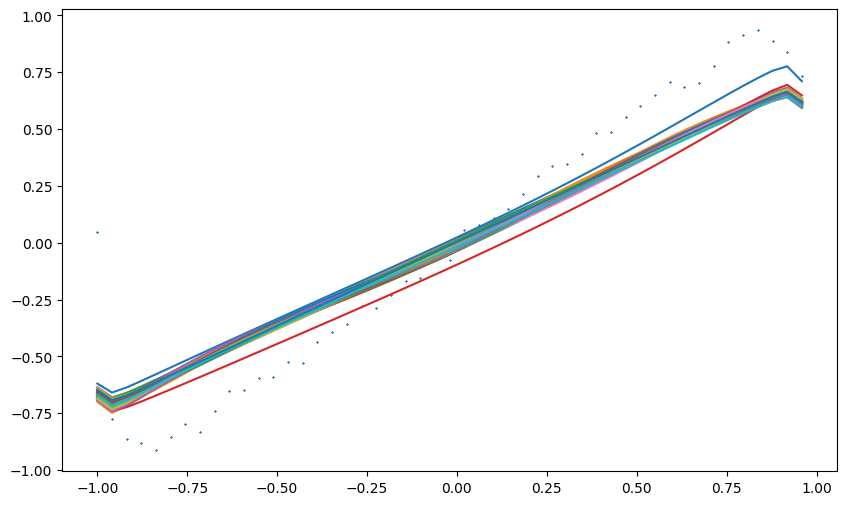

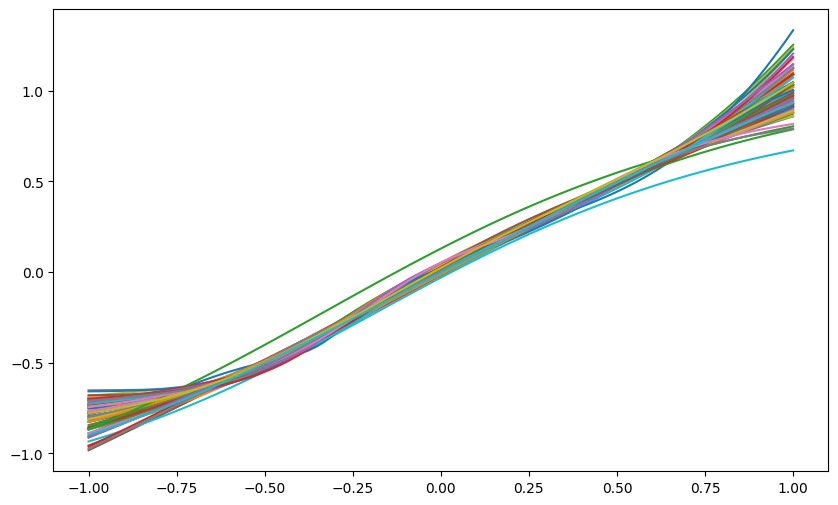

In [14]:
u_train = np.load(pi3nn_results_dir.u_data_path)

plt.figure(figsize=[10, 6])
plt.plot(x_train, u_train, "x", markersize=1)
plt.plot(x_train, ddb_samples.mixed_quantiles, ".")
plt.plot(x_train, ddb_samples.u_train_test, "-")

print(ddb_samples.u_train_test.shape)

plt.figure(figsize=[10, 6])
plt.plot(x_train, u_indis_test, "x", markersize=1)
plt.plot(x_train, ddb_samples.u_in_dis_test, "-")

plt.figure(figsize=[10, 6])
plt.plot(x_train, u_ood_test, "x", markersize=1)
plt.plot(x_train, ddb_samples.u_out_dis_test, "-")

plt.figure(figsize=[10, 6])
plt.plot(ddb_samples.learned_x, ddb_samples.learned_y, "-")

PB

In [15]:
dt = time.time()
pbeng.setup_and_train_pb(pb_results_dir, finn_results_dir)
dt = time.time() - dt
if not (results_dir / "pb_finns_training_time.txt").exists():
    with open(results_dir / "pb_finns_training_time.txt", "w") as file:
        file.write(f"{dt:.2f} s")
    print(f"PB FINNs training time: {dt:.2f} s.")

In [16]:
pb_samples = PBSamples.from_dir(pb_results_dir.path)

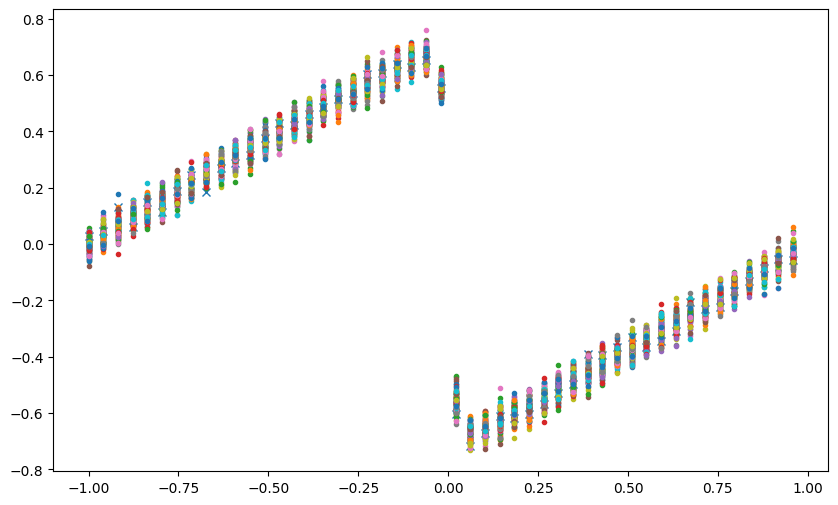

In [17]:
plt.figure(figsize=[10, 6])

u_train = np.load(pi3nn_results_dir.u_data_path)
plt.plot(x_train, u_train, "x")

plt.plot(x_train, pb_samples.bootstraps, '.')

(49, 78)


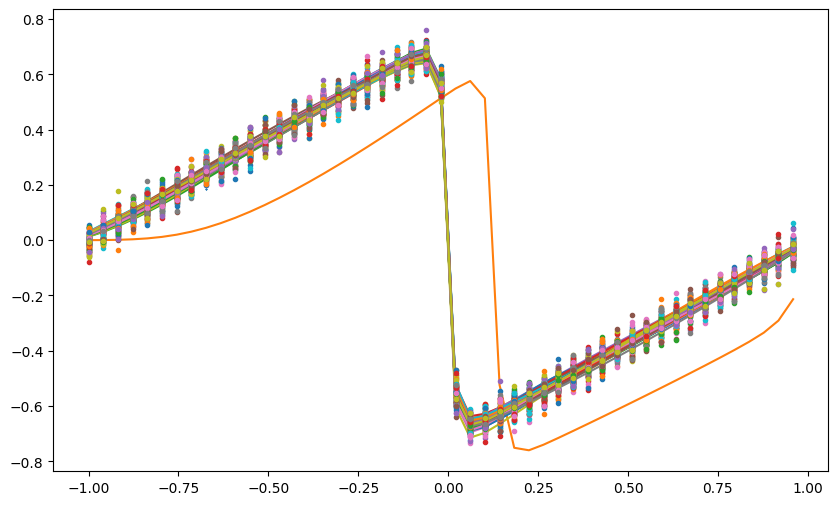

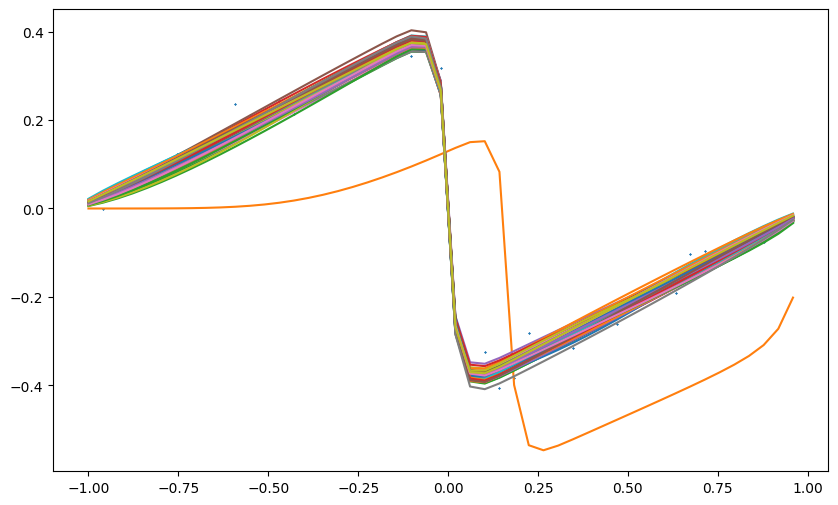

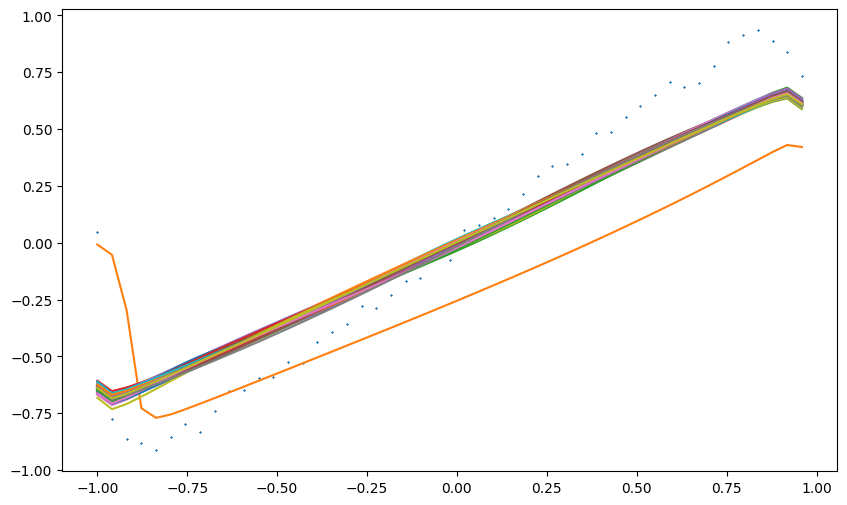

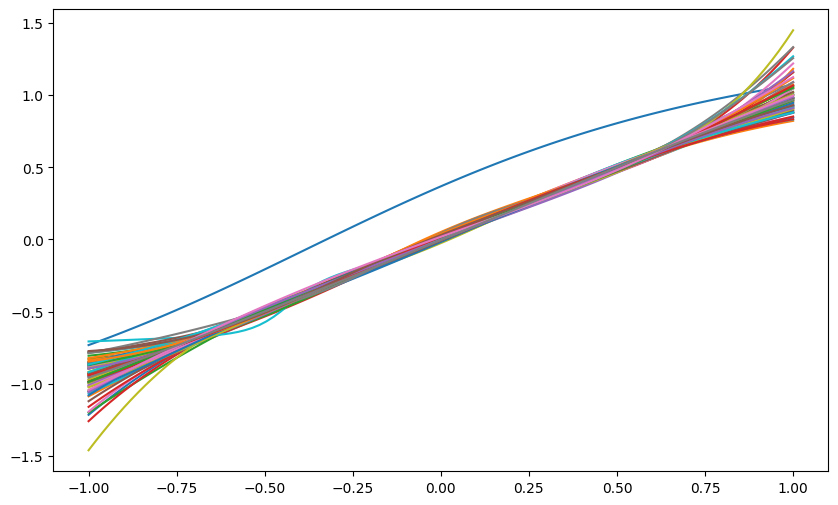

In [18]:
u_train = np.load(pi3nn_results_dir.u_data_path)

print(pb_samples.u_train_test.shape)

plt.figure(figsize=[10, 6])
plt.plot(x_train, u_train, "x", markersize=1)
plt.plot(x_train, pb_samples.u_train_test, "-")
plt.plot(x_train, pb_samples.bootstraps, ".")

plt.figure(figsize=[10, 6])
plt.plot(x_train, u_indis_test, "x", markersize=1)
plt.plot(x_train, pb_samples.u_in_dis_test, "-")

plt.figure(figsize=[10, 6])
plt.plot(x_train, u_ood_test, "x", markersize=1)
plt.plot(x_train, pb_samples.u_out_dis_test, "-")

plt.figure(figsize=[10, 6])
plt.plot(pb_samples.learned_x, pb_samples.learned_y, "-")